<a href="https://colab.research.google.com/github/Carmen10-171/03MIAR_Algoritmos-de-Optimizacion/blob/main/Ponencia_Parte_1_ML_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML Supervisado
## Nuevo Dataset - Cáncer de mama

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, log_loss
import pandas as pd
import numpy as np

# Cargar dataset Breast Cancer
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

"""
Conjunto de datos que recoge características obtenidas de imágenes de tumores de mama
   analizados mediante una técnica llamada citología de aspiración con aguja fina (FNA).

El objetivo es predecir si un tumor es maligno o benigno basándose en sus propiedades.
Tiene 569 muestras y muchas características numéricas, lo que lo hace interesante para clasificación.

Es útil para probar algoritmos supervisados como:
  Regresión logística
  SVM
  Árboles
  KNN
  Redes neuronales
"""


'\nConjunto de datos que recoge características obtenidas de imágenes de tumores de mama\n   analizados mediante una técnica llamada citología de aspiración con aguja fina (FNA).\n\nEl objetivo es predecir si un tumor es maligno o benigno basándose en sus propiedades.\nTiene 569 muestras y muchas características numéricas, lo que lo hace interesante para clasificación.\n\nEs útil para probar algoritmos supervisados como:\n  Regresión logística\n  SVM\n  Árboles\n  KNN\n  Redes neuronales\n'

## LogisticRegression

In [2]:
# Logistic Regressión
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
acc = accuracy_score(y_test, pred)
proba = modelo.predict_proba(X_test)
loss = log_loss(y_test, proba)

print(pd.DataFrame([{'Modelo': 'LogisticRegression', 'Accuracy': acc, 'Log Loss': loss}]))

               Modelo  Accuracy  Log Loss
0  LogisticRegression  0.964912  0.097107


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
"""
ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Significado:
El modelo de LogisticRegression no terminó de optimizar completamente porque
alcanzó el límite de iteraciones establecido (max_iter=1000) antes de encontrar
una solución suficientemente buena según sus criterios.

¿Por qué pasa?
A) El optimizador 'lbfgs' es muy preciso, pero también más exigente.
B) El dataset no está escalado, lo que puede dificultar la convergencia.
C) Puede que 1000 iteraciones no sean suficientes para este caso.
"""


"\nConvergenceWarning: lbfgs failed to converge (status=1):\nSTOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.\n\nSignificado:\nEl modelo de LogisticRegression no terminó de optimizar completamente porque\nalcanzó el límite de iteraciones establecido (max_iter=1000) antes de encontrar\nuna solución suficientemente buena según sus criterios.\n\n¿Por qué pasa?\nA) El optimizador 'lbfgs' es muy preciso, pero también más exigente.\nB) El dataset no está escalado, lo que puede dificultar la convergencia.\nC) Puede que 1000 iteraciones no sean suficientes para este caso.\n"

In [3]:
# Opción 1: Escalamos las variables en el dataset
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
pred = modelo.predict(X_test)
acc = accuracy_score(y_test, pred)
proba = modelo.predict_proba(X_test)
loss = log_loss(y_test, proba)

print(pd.DataFrame([{'Modelo': 'LogisticRegression', 'Accuracy': acc, 'Log Loss': loss}]))

               Modelo  Accuracy  Log Loss
0  LogisticRegression  0.964912  0.097107


In [4]:
# Opción 2: Aumentar max_iter
modelo = LogisticRegression(max_iter=3000)
modelo.fit(X_train, y_train)
pred = modelo.predict(X_test)
acc = accuracy_score(y_test, pred)
proba = modelo.predict_proba(X_test)
loss = log_loss(y_test, proba)

print(pd.DataFrame([{'Modelo': 'LogisticRegression', 'Accuracy': acc, 'Log Loss': loss}]))

               Modelo  Accuracy  Log Loss
0  LogisticRegression  0.964912  0.080972


In [5]:
# Opción 3: Cambiar de solver

# ¿Qué es un Solver?
# Es el algoritmo que se encarga de encontrar los mejores parámetros del modelo
# minimizando la función de pérdida. Es como el "motor" de optimización del modelo.

# En LogisticRegression, ejemplos de solvers son: 'lbfgs', 'liblinear', 'saga', 'newton-cg'.
# Algunos funcionan mejor con pocos datos, otros con muchos, y algunos soportan regularización L1 o L2.

# ¿Qué es regularización L1 y L2?
#
# En Machine Learning, la regularización se usa para evitar que el modelo se sobreentrene (overfitting).
# Imagina que estás construyendo un modelo como si fuera una ecuación con muchos números (coeficientes).
# Si no ponemos límites, el modelo puede aprenderse los datos de memoria (sobreajuste), y no generalizar bien.
# La regularización es como poner una regla que le dice al modelo:
# "usa coeficientes más pequeños o usa menos variables para construir".
# y = X1*C1+X2*C2....+XN*CN+K
# - L1 (también llamado Lasso):
#   Le dice al modelo que use la menor cantidad de variables posible.
#   ¿Cómo? Penaliza el uso de los coeficientes grandes y
#   empuja muchos de ellos a cero.
#   Es útil cuando se sospecha que muchas variables no son importantes.
#
# - L2 (también llamado Ridge):
#   Le dice al modelo que no tenga coeficientes demasiado grandes.
#   No elimina variables, pero suaviza su impacto.
#   Es ideal cuando creemos que todas las variables son
#   útiles pero no queremos que dominen.
#
# En resumen:
# - L1 selecciona variables (porque elimina las que sobran).
# - L2 suaviza (porque hace que todas las variables aporten un poco menos).
# Ambas ayudan a que el modelo generalice mejor a datos nuevos.
# Añade una penalización a la función de pérdida para limitar los valores de los coeficientes.
#
# - L1 (Lasso): penaliza la suma de los valores absolutos de los coeficientes.
#   Tiende a hacer que algunos coeficientes sean exactamente cero (útil para seleccionar variables).
#
# - L2 (Ridge): penaliza la suma de los cuadrados de los coeficientes.
#   Tiende a reducir el tamaño de los coeficientes, pero no los hace cero.
#
# En LogisticRegression puedes elegir qué tipo de regularización aplicar con el parámetro 'penalty'.
#
# En el caso de LogisticRegression, hay varios solvers disponibles:
#
# - 'liblinear': bueno para datasets pequeños, soporta regularización L1 y L2.
# - 'lbfgs': recomendado por defecto, eficiente para datasets medianos a grandes. Solo L2.
# - 'newton-cg': similar a 'lbfgs', útil si hay muchas clases. Solo L2.
# - 'saga': funciona bien con datasets grandes y dispersos. Soporta L1, L2 y elasticnet.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, solver='liblinear')
model.fit(X_train_scaled, y_train)
pred = modelo.predict(X_test)
acc = accuracy_score(y_test, pred)
proba = modelo.predict_proba(X_test)
loss = log_loss(y_test, proba)

print(pd.DataFrame([{'Modelo': 'LogisticRegression', 'Accuracy': acc, 'Log Loss': loss}]))


               Modelo  Accuracy  Log Loss
0  LogisticRegression  0.964912  0.080972


## DecisionTreeClassifier


In [6]:
# Cargar dataset
modelo_tree = DecisionTreeClassifier()
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)

Decision Tree - Accuracy: 0.9649122807017544 Log Loss: 1.2646895926006019


In [7]:
# Decision Tree - Técnicas para mejorar log_loss
# 1. Limitar profundidad del árbol (max_depth) para evitar overfitting.
# 2. Ajustar min_samples_leaf y min_samples_split para generalizar mejor.
# 3. Podar el árbol usando ccp_alpha con cost-complexity pruning.
# 4. Usar ensemble methods como RandomForest o GradientBoosting para mejores probabilidades.


In [8]:
# Opción 1:
# Limitar profundidad del árbol (max_depth) para evitar overfitting.
modelo_tree = DecisionTreeClassifier(max_depth=4)
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)
# Cuando un árbol es muy profundo, aprende demasiado bien los datos de entrenamiento,
# incluyendo el ruido, y generaliza mal a nuevos datos.
# Al limitar la profundidad, obligamos al árbol a tomar decisiones más generales y robustas.

Decision Tree - Accuracy: 0.9649122807017544 Log Loss: 0.9753898479071402


In [9]:
# Opción 2:
# También podemos ajustar los parámetros min_samples_leaf y min_samples_split.
# min_samples_leaf: número mínimo de muestras que debe tener una hoja.
#   Aumentarlo evita que el árbol cree hojas con pocos datos (más generalización).
# min_samples_split: número mínimo de muestras para dividir un nodo.
#   Evita divisiones irrelevantes si se establece un mínimo razonable.

modelo_tree = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, min_samples_split=10)
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)

Decision Tree - Accuracy: 0.9298245614035088 Log Loss: 0.13996091315241352


In [14]:
# Opción 2.1:
# ¿Cómo encontramos la mejor combinación?
from sklearn.model_selection import GridSearchCV

# Búsqueda exhaustiva

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_leaf': [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, scoring='neg_log_loss', cv=10)
# GridSearchCV siempre intenta maximizar la puntuación, por eso espera que sea "cuanto más alto, mejor".
# Pero el log_loss es un error (lo queremos minimizar), así que hay que invertirlo.
# Para ello, siempre debes usar 'neg_log_loss' (log_loss negativo), de modo que:
# - Un valor más alto de 'neg_log_loss' significa un log_loss más bajo (mejor modelo).
# - El modelo con el mayor 'neg_log_loss' será el que tenga el menor log_loss real.

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Mejor combinación encontrada:", grid.best_params_)

# Evaluar en test
pred = best_model.predict(X_test)
proba = best_model.predict_proba(X_test)
acc = accuracy_score(y_test, pred)
loss = log_loss(y_test, proba)

print("Accuracy:", acc)
print("Log Loss:", loss)


Mejor combinación encontrada: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Accuracy: 0.9210526315789473
Log Loss: 1.022204491408412


In [15]:
# Opción 2.2:
#¿Y si vamos probando más combinaciones de manera aleatoria?
# En lugar de probar todas las combinaciones, prueba un número fijo de combinaciones aleatorias.

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    'max_depth': randint(3, 15),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 20)
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(), param_distributions=param_dist,
    n_iter=100, scoring='neg_log_loss', cv=10, random_state=2025
)
rand_search.fit(X_train, y_train)

print("Mejores parámetros:", rand_search.best_params_)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)

Mejores parámetros: {'max_depth': 3, 'min_samples_leaf': 19, 'min_samples_split': 6}
Decision Tree - Accuracy: 0.9385964912280702 Log Loss: 0.17742023867531637


In [16]:
# Opción 3:
# Podar el árbol usando ccp_alpha con cost-complexity pruning.
# Este parámetro controla cuánto se penaliza la complejidad del árbol.
# Valores mayores de ccp_alpha dan árboles más simples.
# Entrenamos un árbol inicial para obtener valores candidatos de ccp_alpha
path = DecisionTreeClassifier(random_state=2025).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Elegimos un valor de ejemplo razonable (no demasiado bajo ni alto)
modelo_tree = DecisionTreeClassifier(random_state=2025, ccp_alpha=ccp_alphas[-2])
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)


Decision Tree - Accuracy: 0.9122807017543859 Log Loss: 0.30167235919434654


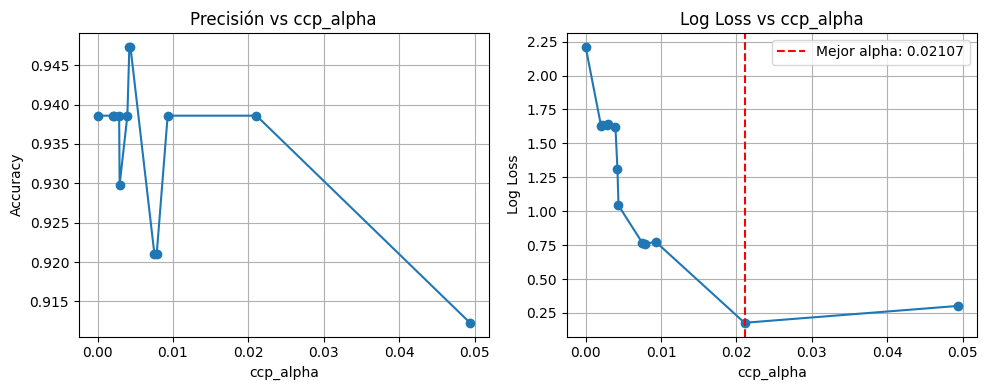

Decision Tree - Accuracy: 0.9385964912280702 Log Loss: 0.17742023867531637


In [17]:
# Opción 3.1, vamos a verlo graficamente

# Entrenamos un árbol inicial para obtener valores candidatos de ccp_alpha
path = DecisionTreeClassifier(random_state=2025).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

# Elegimos un valor de ejemplo (no demasiado bajo ni alto)
# Y visualizamos cómo afecta ccp_alpha a la precisión y log_loss
import matplotlib.pyplot as plt

accuracies = []
log_losses = []
alpha_values = ccp_alphas[:-1]  # evitamos el último que deja un árbol vacío

for alpha in alpha_values:
    tree = DecisionTreeClassifier(random_state=2025, ccp_alpha=alpha)
    tree.fit(X_train, y_train)
    pred = tree.predict(X_test)
    acc = accuracy_score(y_test, pred)
    try:
        proba = tree.predict_proba(X_test)
        loss = log_loss(y_test, proba)
    except:
        loss = None
    accuracies.append(acc)
    log_losses.append(loss)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(alpha_values, accuracies, marker='o')
plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Precisión vs ccp_alpha")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(alpha_values, log_losses, marker='o')

# Resaltar el mejor valor
min_loss = min(log_losses)
best_alpha = alpha_values[log_losses.index(min_loss)]
plt.axvline(best_alpha, color='red', linestyle='--', label=f'Mejor alpha: {best_alpha:.5f}')
plt.legend()
plt.xlabel("ccp_alpha")
plt.ylabel("Log Loss")
plt.title("Log Loss vs ccp_alpha")
plt.grid(True)

plt.tight_layout()
plt.show()

# Finalmente usamos el mejor valor de ccp_alpha encontrado automáticamente
modelo_tree = DecisionTreeClassifier(random_state=2025, ccp_alpha=best_alpha)
modelo_tree.fit(X_train, y_train)
pred_tree = modelo_tree.predict(X_test)
proba_tree = modelo_tree.predict_proba(X_test)
acc_tree = accuracy_score(y_test, pred_tree)
loss_tree = log_loss(y_test, proba_tree)
print("Decision Tree - Accuracy:", acc_tree, "Log Loss:", loss_tree)


In [18]:
# 4. Usar ensemble methods como RandomForest o GradientBoosting para mejores probabilidades.
# Ensemble methods para mejorar la probabilidad
# Usar RandomForest o GradientBoosting que combinan muchos árboles y suelen dar mejores resultados

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Random Forest
modelo_rf = RandomForestClassifier(random_state=2025)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)
proba_rf = modelo_rf.predict_proba(X_test)
acc_rf = accuracy_score(y_test, pred_rf)
loss_rf = log_loss(y_test, proba_rf)
print("Random Forest - Accuracy:", acc_rf, "Log Loss:", loss_rf)

# Gradient Boosting
modelo_gb = GradientBoostingClassifier(random_state=2025)
modelo_gb.fit(X_train, y_train)
pred_gb = modelo_gb.predict(X_test)
proba_gb = modelo_gb.predict_proba(X_test)
acc_gb = accuracy_score(y_test, pred_gb)
loss_gb = log_loss(y_test, proba_gb)
print("Gradient Boosting - Accuracy:", acc_gb, "Log Loss:", loss_gb)

# Estos métodos combinan múltiples árboles para formar un modelo más robusto.
# - RandomForest entrena muchos árboles de decisión en paralelo y vota entre ellos.
#   Construye muchos árboles de decisión independientes usando partes distintas del dataset (con reemplazo).
#   Luego vota entre los árboles (en clasificación) o hace el promedio (en regresión).
#   Esto reduce el sobreajuste de un solo árbol y mejora la estabilidad.
#
# - GradientBoosting entrena árboles uno tras otro, corrigiendo los errores del anterior.
#   Entrena árboles uno por uno, y cada árbol intenta corregir los errores del anterior.
#   La predicción final es una suma ponderada de todos los árboles.
#
# Estos modelos ayudan a reducir el sobreajuste y mejoran la calidad de las probabilidades que se generan.
#
# "Un árbol solo puede equivocarse si toma una mala decisión.
# Pero si preguntas a 100 árboles (Random Forest), es más difícil que todos se equivoquen a la vez.
# Y si dejas que cada nuevo árbol aprenda de los errores del anterior (Boosting), aún mejor."

Random Forest - Accuracy: 0.956140350877193 Log Loss: 0.0831658426433284
Gradient Boosting - Accuracy: 0.9736842105263158 Log Loss: 0.06989520561781129


## KNN

In [19]:
from sklearn.neighbors import KNeighborsClassifier

# KNN - K Nearest Neighbors
# Este algoritmo clasifica un registro basándose en las clases de sus vecinos más cercanos.

modelo_knn = KNeighborsClassifier()
modelo_knn.fit(X_train, y_train)
pred_knn = modelo_knn.predict(X_test)
proba_knn = modelo_knn.predict_proba(X_test)
acc_knn = accuracy_score(y_test, pred_knn)
loss_knn = log_loss(y_test, proba_knn)
print("KNN - Accuracy:", acc_knn, "Log Loss:", loss_knn)

# ¿Cómo mejorar el log_loss en KNN?
# 1. Ajustar n_neighbors
# 2. Cambiar los pesos: usar 'distance' en lugar de 'uniform' para que los vecinos más cercanos pesen más.
# 3. Estandarizar los datos: KNN depende de distancias, así que escalar las variables ayuda mucho.
# 4. Buscar la mejor combinación con GridSearchCV o RandomizedSearchCV.


KNN - Accuracy: 0.9210526315789473 Log Loss: 1.347064450652884


In [20]:
# 1. Ajustar n_neighbors (número de vecinos)
# Para encontrar el valor óptimo de n_neighbors, se puede usar GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_neighbors': list(range(1, 21))  # probar de 1 a 20 vecinos
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, scoring='neg_log_loss', cv=10)
grid_knn.fit(X_train, y_train)

best_k = grid_knn.best_params_['n_neighbors']
print("Mejor número de vecinos (n_neighbors):", best_k)

# Reentrenar con el mejor valor encontrado
modelo_knn_1 = KNeighborsClassifier(n_neighbors=best_k)
modelo_knn_1.fit(X_train, y_train)
pred_1 = modelo_knn_1.predict(X_test)
proba_1 = modelo_knn_1.predict_proba(X_test)
print("n_neighbors óptimo - Accuracy:", accuracy_score(y_test, pred_1), "Log Loss:", log_loss(y_test, proba_1))


Mejor número de vecinos (n_neighbors): 16
n_neighbors óptimo - Accuracy: 0.9385964912280702 Log Loss: 0.46270596626122124


In [21]:
# 2. Cambiar pesos a 'distance'
# Por defecto, KNN considera que todos los vecinos pesan igual ('uniform')
# Cambiando a 'distance', los vecinos más cercanos tienen más influencia en la predicción
# Esto puede mejorar la calidad de las probabilidades devueltas y reducir el log loss
modelo_knn_2 = KNeighborsClassifier(n_neighbors=16, weights='distance')
modelo_knn_2.fit(X_train, y_train)
pred_2 = modelo_knn_2.predict(X_test)
proba_2 = modelo_knn_2.predict_proba(X_test)
print("weights='distance' - Accuracy:", accuracy_score(y_test, pred_2), "Log Loss:", log_loss(y_test, proba_2))

weights='distance' - Accuracy: 0.9385964912280702 Log Loss: 0.4685100515123318


In [22]:
# 3. Escalar características (KNN depende de distancias)
# KNN calcula distancias entre cada registro que procesa, por lo que si las características están en escalas diferentes,
# unas influirán más que otras (por ejemplo, si una variable está en mm y otra en cm).

# Estandarizar (media 0, desviación 1) hace que todas las variables contribuyan por igual a la distancia.
# Esto suele mejorar el rendimiento y, en particular, la calidad de las probabilidades.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_knn_3 = KNeighborsClassifier(n_neighbors=16, weights='distance')
modelo_knn_3.fit(X_train_scaled, y_train)
pred_3 = modelo_knn_3.predict(X_test_scaled)
proba_3 = modelo_knn_3.predict_proba(X_test_scaled)
print("KNN escalado - Accuracy:", accuracy_score(y_test, pred_3), "Log Loss:", log_loss(y_test, proba_3))


KNN escalado - Accuracy: 0.9912280701754386 Log Loss: 0.05734463863788066


In [23]:
# 4. Buscar la mejor combinación con GridSearchCV incluyendo escalado y pesos
from sklearn.pipeline import Pipeline

param_grid = {
    'knn__n_neighbors': list(range(1, 21)),
    'knn__weights': ['uniform', 'distance']
}

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

grid_knn_full = GridSearchCV(pipeline, param_grid, scoring='neg_log_loss', cv=10)
grid_knn_full.fit(X_train, y_train)

best_params = grid_knn_full.best_params_
best_model = grid_knn_full.best_estimator_

pred_grid = best_model.predict(X_test)
proba_grid = best_model.predict_proba(X_test)
print("Mejor combinación encontrada:", best_params)
print("KNN optimizado - Accuracy:", accuracy_score(y_test, pred_grid), "Log Loss:", log_loss(y_test, proba_grid), "Log Loss:", log_loss(y_test, proba_3))


Mejor combinación encontrada: {'knn__n_neighbors': 12, 'knn__weights': 'distance'}
KNN optimizado - Accuracy: 0.9912280701754386 Log Loss: 0.053330475588757184 Log Loss: 0.05734463863788066


## Support Vector Machine

In [24]:
# SVM
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, log_loss
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# Cargar dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# 1. Entrenamiento básico con SVC
modelo_svc = SVC(probability=True, random_state=2025)
modelo_svc.fit(X_train, y_train)
pred_svc = modelo_svc.predict(X_test)
proba_svc = modelo_svc.predict_proba(X_test)
print("SVC (básico) - Accuracy:", accuracy_score(y_test, pred_svc), "Log Loss:", log_loss(y_test, proba_svc))

# SVM es una técnica que intenta encontrar la mejor forma de separar estas las clases (tumor maligno o benigno).
# En lugar de buscar una fórmula complicada, SVM intenta dibujar una línea
# (o un plano si hay muchas variables, en nuestro caso hay 30 variables)
# Esta línea o plano intenta separar a los casos malignos a un lado y a los benignos al otro, con el mayor espacio posible entre ellos.
# Esa línea imaginaria se llama "hiperplano de separación".
#
# Los datos que están más cerca de esa línea son los más importantes: se llaman "vectores de soporte".
# Son los que empujan y tiran de esa línea para definir su posición final.
# Son los que definen la posición exacta de esa frontera.

# Por cierto, SVM (Support Vector Machine) es el concepto o la técnica general.
# SVC (Support Vector Classifier) es la implementación específica de clasificación de SVM en scikit-learn.
# SVR (para la Regresión)


# ¿Qué hace el parámetro C?

# El parámetro C controla cuánto penaliza el modelo los errores de clasificación.
# - Si C es muy alto: el modelo intenta clasificar todo correctamente,
#   incluso si eso significa ajustarse demasiado a los datos (riesgo de sobreajuste).
# - Si C es más bajo: el modelo acepta más errores a cambio de una frontera
#   de decisión más simple y generalizable (mejor generalización).

# Ejemplo con diferentes valores:
modelo_svc_suave = SVC(C=0.1, kernel='rbf', probability=True)
modelo_svc_suave.fit(X_train, y_train)
pred_suave = modelo_svc_suave.predict(X_test)
proba_suave = modelo_svc_suave.predict_proba(X_test)
print("SVC (C=0.1, suave) - Accuracy:", accuracy_score(y_test, pred_suave), "Log Loss:", log_loss(y_test, proba_suave))

modelo_svc_estricto = SVC(C=100, kernel='rbf', probability=True)
modelo_svc_estricto.fit(X_train, y_train)
pred_estricto = modelo_svc_estricto.predict(X_test)
proba_estricto = modelo_svc_estricto.predict_proba(X_test)
print("SVC (C=100, estricto) - Accuracy:", accuracy_score(y_test, pred_estricto), "Log Loss:", log_loss(y_test, proba_estricto))



SVC (básico) - Accuracy: 0.9035087719298246 Log Loss: 0.22772032080765814
SVC (C=0.1, suave) - Accuracy: 0.8947368421052632 Log Loss: 0.25450184629481387
SVC (C=100, estricto) - Accuracy: 0.9298245614035088 Log Loss: 0.1817042110602553


In [25]:
# ¿Qué hace cada kernel?
# El kernel es la herramienta matemática que usa SVM para decidir cómo separar los datos.
# - 'linear': intenta separar los datos con una línea recta (útil cuando los datos ya están bien separados).
# - 'poly': usa curvas polinómicas para separar los datos si no se pueden dividir con una línea recta.
# - 'rbf': es el más flexible ya que crea curvas suaves
# - 'sigmoid': se parece al funcionamiento de una neurona (poco usado en la práctica ya que es más potente usar una DNN).
# Elegir el kernel adecuado depende de cómo se distribuyen los datos en tu problema.
# Comparación de kernels en SVM
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss

# Cargar y preparar el dataset
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Lista de kernels a evaluar
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

# Evaluar cada kernel
for k in kernels:
    # Comentarios explicativos para cada kernel
    if k == 'linear':
        print("\nKernel: 'linear'")
    elif k == 'poly':
        print("\nKernel: 'poly'")
    elif k == 'rbf':
        print("\nKernel: 'rbf'")
    elif k == 'sigmoid':
        print("\nKernel: 'sigmoid'")

    modelo = SVC(kernel=k, C=100.0, gamma='scale', probability=True)
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    proba = modelo.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    loss = log_loss(y_test, proba)
    print(f"Accuracy: {acc:.4f} - Log Loss: {loss:.4f}")



Kernel: 'linear'
Accuracy: 0.9825 - Log Loss: 0.0602

Kernel: 'poly'
Accuracy: 0.9912 - Log Loss: 0.0926

Kernel: 'rbf'
Accuracy: 0.9737 - Log Loss: 0.0756

Kernel: 'sigmoid'
Accuracy: 0.9474 - Log Loss: 0.3208


gamma=0.001 - Accuracy: 1.0000 - Log Loss: 0.0527
gamma=0.01 - Accuracy: 1.0000 - Log Loss: 0.0367
gamma=0.1 - Accuracy: 0.9737 - Log Loss: 0.0763
gamma=1 - Accuracy: 0.5965 - Log Loss: 0.4208
gamma=10 - Accuracy: 0.5965 - Log Loss: 0.6781


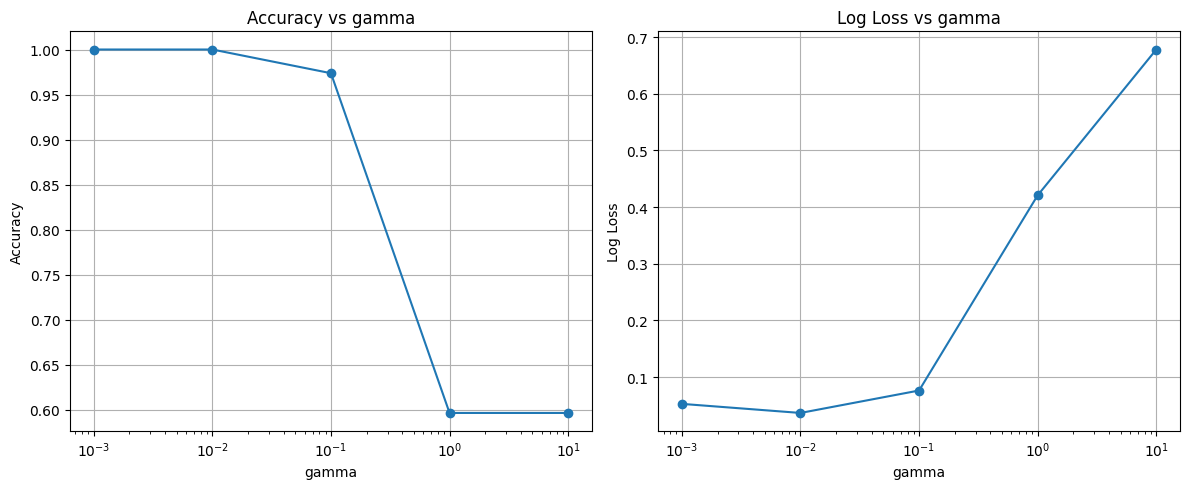

In [26]:
# SVM calcula distancias entre puntos.
# Si una variable está en una escala muy distinta (por ejemplo, 0–1 vs 0–1000),
# esa variable dominará la distancia.
# Esto hace que el modelo: aprenda mal y sea sensible a valores fuera de escala
# Por ende, va a tener fronteras de decisión poco útiles
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2025)

# Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Evaluación de distintos valores de gamma
gammas = [0.001, 0.01, 0.1, 1, 10]
resultados = []

for g in gammas:
    modelo = SVC(kernel='rbf', gamma=g, C=1.0, probability=True)
    modelo.fit(X_train_scaled, y_train)
    pred = modelo.predict(X_test_scaled)
    proba = modelo.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, pred)
    loss = log_loss(y_test, proba)
    resultados.append({'gamma': g, 'accuracy': acc, 'log_loss': loss})

# Mostrar resultados
for res in resultados:
    print(f"gamma={res['gamma']} - Accuracy: {res['accuracy']:.4f} - Log Loss: {res['log_loss']:.4f}")

# Visualización
gammas = [r['gamma'] for r in resultados]
accs = [r['accuracy'] for r in resultados]
losses = [r['log_loss'] for r in resultados]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(gammas, accs, marker='o')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Accuracy')
plt.title('Accuracy vs gamma')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gammas, losses, marker='o')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Log Loss')
plt.title('Log Loss vs gamma')
plt.grid(True)

plt.tight_layout()
plt.show()

#Con gamma muy pequeño (0.001, 0.01): el modelo crea una frontera de decisión suave, generaliza bien.
# Con gamma muy alto (1 o 10): el modelo trata de ajustarse demasiado a los datos
# Por ende, cuida demasiado la frontera, por lo que pierde generalización y falla en los datos nuevos.
# Mirad: gamma=0.01 - Accuracy: 1.0000 - Log Loss: 0.0373


Validación cruzada - Accuracy medio: 0.973719806763285
Desviación estándar: 0.02136139895807624


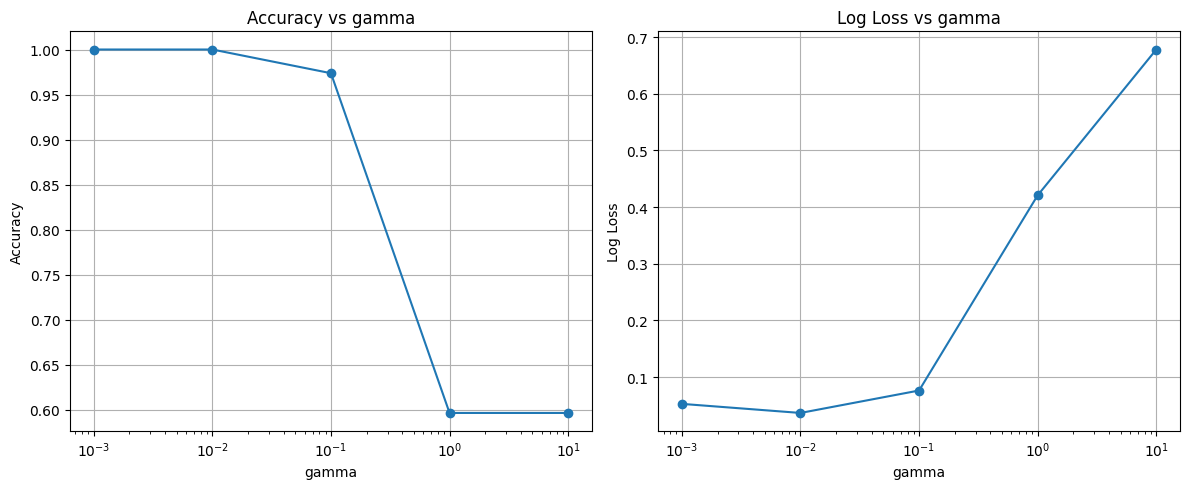

In [27]:
# ¿Estamos sobreajustando?
# Verificación de posible sobreajuste usando validación cruzada
from sklearn.model_selection import cross_val_score

# Usamos el mejor gamma observado (por ejemplo 0.01) para comprobar estabilidad con validación cruzada
modelo_cv = SVC(kernel='rbf', gamma=0.01, C=1.0, probability=True)
scores = cross_val_score(modelo_cv, X_train_scaled, y_train, cv=10, scoring='accuracy')
print("Validación cruzada - Accuracy medio:", scores.mean())
print("Desviación estándar:", scores.std())

# Visualización
gammas = [r['gamma'] for r in resultados]
accs = [r['accuracy'] for r in resultados]
losses = [r['log_loss'] for r in resultados]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(gammas, accs, marker='o')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Accuracy')
plt.title('Accuracy vs gamma')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(gammas, losses, marker='o')
plt.xscale('log')
plt.xlabel('gamma')
plt.ylabel('Log Loss')
plt.title('Log Loss vs gamma')
plt.grid(True)

plt.tight_layout()
plt.show()

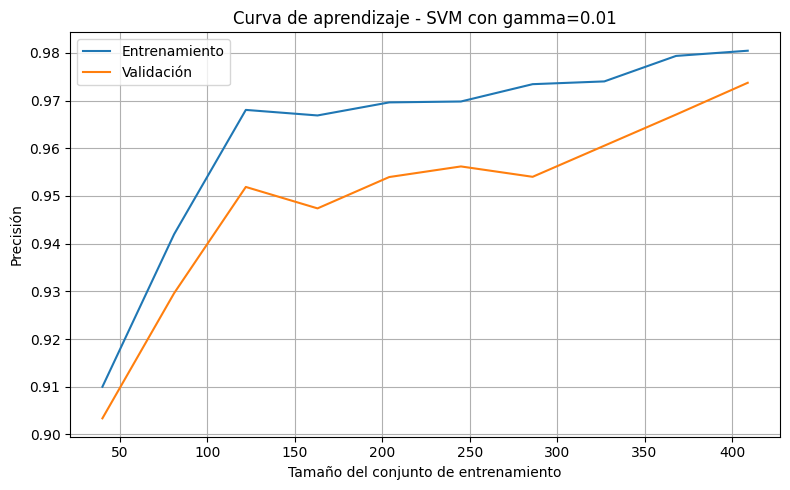

In [ ]:
# Curva de aprendizaje para detectar sobreajuste
from sklearn.model_selection import learning_curve

train_sizes, train_scores, test_scores = learning_curve(
    modelo_cv, X_train_scaled, y_train, cv=10, scoring='accuracy', train_sizes=np.linspace(0.1, 1.0, 10), random_state=2025
)

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Entrenamiento')
plt.plot(train_sizes, test_mean, label='Validación')
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Precisión")
plt.title("Curva de aprendizaje - SVM con gamma=0.01")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Conclusiones



In [ ]:
# ===============================================================
# Conceptros al comparar modelos supervisados
# ===============================================================

# Algunos modelos son más fáciles de usar que otros:
# LogisticRegression funciona muy bien y se entrena rápido.
# KNN es simple pero necesita escalar los datos.
# Árboles no requieren escalado y son fáciles de interpretar.
# SVM necesita ajustar bien los parámetros (C, gamma, kernel).

# Escalar es importante si el modelo usa distancias (KNN, SVM).
# No escalar puede afectar mucho los resultados.

# Tener buen log_loss significa que el modelo no solo acierta,
# sino que también da buenas probabilidades (seguras y calibradas).

# ===============================================================
# ¿Cuándo usar qué algoritmo?
# ===============================================================

# LogisticRegression: Si los datos se separan con una línea.
# Para saberlo, representa los datos.

# KNN: Si tiene sentido agrupar datos.
# Fácil de entender, pero sensible a la escala.

# Árboles: Si quieres un modelo que puedas explicar fácilmente.
# No necesitan escalar y manejan bien diferentes tipos de datos.

# SVM: Si los datos no se separan bien con una línea recta.
# Muy potente, pero hay que ajustar con cuidado para evitar sobreajuste.


# Vamos a pasar a Algoritmos NO supervisados